# Mind Reader: Bank Marketing Decision Tree

B.Y.T.E Data Science — Task 4

Predict term-deposit subscription and explain each prediction with SHAP.

Dataset: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing), Moro, Rita & Cortez, CC BY 4.0. Use `bank-full.csv`, 45,211 rows, 16 original inputs and target `y`. Balances are euros. Download is automatic; raw data stays out of Git.

## Experimental design

Exclude duration; preserve unknown categories and pdays=-1. Same stratified 80/20 split, seed 42. One-hot encoding is fitted inside each training fold. The optional contact indicator is derived from pdays.

experiment.py compares seven prior-setting variants and 48 seeded random configurations: depths 6/8/10/12; maximum leaves 32/64/128; minimum leaf sizes 20/50/100; pruning alpha 0/.0001/.0005/.001; Gini/entropy; no weights, balanced, 2x or 4x positive weights.

For each of five validation folds (seed 2026), use three inner folds on its training portion to select an F1 cutoff, refit on that training portion, and evaluate on the separate validation fold. Choose the highest mean validation F1; ties prefer fewer leaves. These means are model-selection scores, not unbiased performance estimates. Historical configurations were already explored on the training data, so these comparisons are diagnostic, not a pristine benchmark.

Freeze the winner. Tune its final cutoff on three out-of-fold partitions of all training data (seed 314), then fit on all training data. The existing test split is excluded from this selection but has been inspected before. Report its scores as a same-split regression comparison. Schedule and contact count must be known before prediction.

The full experiment and export code are embedded below. This notebook reuses the saved training-only selection to avoid repeating the expensive search, validates the dataset/split fingerprints, reloads the fitted model, and recomputes evaluation and exports. Set reuse_selection=False (or call train()) to rerun the entire search. No test metric is used to choose the winner.


In [1]:
"""Training-only tree experiments with separately validated threshold selection.

Run: python -u experiment.py
The existing 20% test partition is excluded from this module's model selection.
"""
import json
import hashlib
from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
from joblib import Parallel, delayed, dump
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split, ParameterSampler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, accuracy_score, average_precision_score
from train import load_data, ROOT

def make_pipeline(X, params):
    categorical = X.select_dtypes(include=['object', 'str']).columns.tolist()
    numeric = [c for c in X if c not in categorical]
    prep = ColumnTransformer([('num','passthrough',numeric), ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical)])
    return Pipeline([('preprocess',prep),('model',DecisionTreeClassifier(random_state=42,**params))])

def choose_cutoff(y, scores):
    precision, recall, thresholds = precision_recall_curve(y,scores)
    total = precision[:-1]+recall[:-1]
    f1 = np.divide(2*precision[:-1]*recall[:-1],total,out=np.zeros_like(total),where=total>0)
    best = np.flatnonzero(np.isclose(f1,f1.max(),atol=1e-12,rtol=0))[-1]
    return float(thresholds[best]), pd.DataFrame({'threshold':thresholds,'precision':precision[:-1],'recall':recall[:-1],'f1':f1})

def tuned_fit(X,y,params,seed):
    pipeline = make_pipeline(X,params)
    inner = StratifiedKFold(3,shuffle=True,random_state=seed)
    oof = np.zeros(len(y))
    for fit_ids,calibration_ids in inner.split(X,y):
        fitted=clone(pipeline).fit(X.iloc[fit_ids],y.iloc[fit_ids])
        oof[calibration_ids]=fitted.predict_proba(X.iloc[calibration_ids])[:,1]
    threshold,curve=choose_cutoff(y,oof)
    pipeline.fit(X,y)
    return pipeline,threshold,curve

def candidate_score(candidate,X,y,splits):
    features=X if candidate['indicator'] else X.drop(columns='previously_contacted')
    rows=[]
    for fold,(fit_ids,validation_ids) in enumerate(splits):
        fit_X,fit_y=features.iloc[fit_ids],y.iloc[fit_ids]
        if candidate['tuned']:
            pipeline,threshold,_=tuned_fit(fit_X,fit_y,candidate['params'],100+fold)
        else:
            pipeline=make_pipeline(fit_X,candidate['params']).fit(fit_X,fit_y)
            threshold=.5
        scores=pipeline.predict_proba(features.iloc[validation_ids])[:,1]
        pred=(scores>=threshold).astype(int)
        actual=y.iloc[validation_ids]
        rows.append({'candidate':candidate['name'],'fold':fold+1,'threshold':threshold,
                     'f1':float(f1_score(actual,pred)), 'precision':float(precision_score(actual,pred,zero_division=0)),
                     'recall':float(recall_score(actual,pred)), 'accuracy':float(accuracy_score(actual,pred)),
                     'average_precision':float(average_precision_score(actual,scores)),
                     'leaves':pipeline.named_steps['model'].get_n_leaves()})
    return candidate,rows

def run_experiment():
    df=load_data()
    X=df.drop(columns=['y','duration']).assign(previously_contacted=(df.pdays!=-1).astype(int))
    y=df.y.eq('yes').astype(int)
    X_train,_,y_train,_=train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
    original={'class_weight':'balanced','criterion':'gini','max_depth':5,'max_leaf_nodes':8,'min_samples_leaf':150}
    capacity={**original,'max_depth':6,'max_leaf_nodes':32,'min_samples_leaf':50}
    previous={**capacity,'criterion':'entropy'}
    candidates=[]
    for name,params in [('v1',original),('capacity_only',capacity),('v2',previous)]:
        for tuned in [False,True]:
            candidates.append({'name':f'{name}_{"tuned" if tuned else "fixed"}','params':params,'tuned':tuned,'indicator':name!='v1'})
    candidates.append({'name':'v2_no_indicator_tuned','params':previous,'tuned':True,'indicator':False})
    grid={'max_depth':[6,8,10,12], 'max_leaf_nodes':[32,64,128], 'min_samples_leaf':[20,50,100],
          'ccp_alpha':[0.,.0001,.0005,.001], 'criterion':['gini','entropy'],
          'class_weight':[None,'balanced',{0:1,1:2},{0:1,1:4}]}
    for i,params in enumerate(ParameterSampler(grid,n_iter=48,random_state=73)):
        candidates.append({'name':f'expanded_{i+1:02d}','params':params,'tuned':True,'indicator':True})
    splits=list(StratifiedKFold(5,shuffle=True,random_state=2026).split(X_train,y_train))
    out=ROOT/'outputs/experiment';out.mkdir(parents=True,exist_ok=True)
    (out/'design.json').write_text(json.dumps({'candidates':candidates,'outer_folds':5,'inner_folds':3,'selection':'mean outer validation F1; ties prefer fewer leaves','test_used':False,'seed':2026},indent=2),encoding='utf-8')
    all_rows=[]; summary=[]
    # Thread workers avoid Windows process shutdown/memmap issues; limit to two.
    jobs=Parallel(n_jobs=2,prefer='threads',return_as='generator')(delayed(candidate_score)(c,X_train,y_train,splits) for c in candidates)
    for count,(candidate,rows) in enumerate(jobs,1):
        all_rows.extend(rows)
        values=pd.DataFrame(rows)
        record={'candidate':candidate['name'],'mean_f1':float(values.f1.mean()),'std_f1':float(values.f1.std(ddof=1)),
                **{f'mean_{key}':float(values[key].mean()) for key in ['precision','recall','accuracy','average_precision','leaves']},
                'params':json.dumps(candidate['params'],sort_keys=True),'tuned':candidate['tuned'],'indicator':candidate['indicator']}
        summary.append(record)
        pd.DataFrame(all_rows).to_csv(out/'fold_results.csv',index=False)
        pd.DataFrame(summary).sort_values(['mean_f1','mean_leaves'],ascending=[False,True]).to_csv(out/'candidate_results.csv',index=False)
        print(f"{count}/{len(candidates)} {candidate['name']}: validation F1={record['mean_f1']:.4f}",flush=True)
    table=pd.DataFrame(summary).sort_values(['mean_f1','mean_leaves'],ascending=[False,True])
    winner_name=table.iloc[0].candidate
    winner=next(c for c in candidates if c['name']==winner_name)
    # Lock the winner using training validation before accessing test outcomes.
    selected_X=X_train if winner['indicator'] else X_train.drop(columns='previously_contacted')
    if winner['tuned']:
        pipeline,threshold,curve=tuned_fit(selected_X,y_train,winner['params'],314)
    else:
        pipeline=make_pipeline(selected_X,winner['params']).fit(selected_X,y_train);threshold=.5;curve=pd.DataFrame()
    curve.to_csv(out/'final_threshold_search.csv',index=False)
    selection={'winner':winner,'threshold':threshold,'mean_validation_f1':float(table.iloc[0].mean_f1),
               'incumbent_validation_f1':float(table.loc[table.candidate=='v2_tuned','mean_f1'].iloc[0]),
               'csv_sha256':hashlib.sha256((ROOT/'data/bank-full.csv').read_bytes()).hexdigest(),
               'training_indices_sha256':hashlib.sha256(np.asarray(X_train.index,dtype=np.int64).tobytes()).hexdigest(),
               'selection_bias_note':'Outer folds are used to choose among 55 candidates; the winning mean is a selection score, not an unbiased final estimate. Existing test split has been inspected before.'}
    (out/'selection.json').write_text(json.dumps(selection,indent=2),encoding='utf-8')
    dump({'pipeline':pipeline,'decision_threshold':threshold,'selection':selection},out/'selected_pipeline.joblib')
    print(json.dumps(selection,indent=2),flush=True)
    return table,selection




In [2]:
"""Reproducible training and browser artifact export. Run with Python 3.12+."""
from pathlib import Path
from io import BytesIO
import hashlib
import json
import zipfile
import os
import warnings
from urllib.request import urlopen
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd()/'.runtime/matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore', message='IProgress not found.*')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, roc_auc_score
from joblib import dump, load

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
URL = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'

def load_data():
    path = ROOT / 'data/bank-full.csv'
    path.parent.mkdir(exist_ok=True)
    if not path.exists():
        with urlopen(URL, timeout=90) as response:
            outer = zipfile.ZipFile(BytesIO(response.read()))
        if 'bank-full.csv' in outer.namelist():
            raw = outer.read('bank-full.csv')
        else:
            inner = zipfile.ZipFile(BytesIO(outer.read('bank.zip')))
            raw = inner.read('bank-full.csv')
        path.write_bytes(raw)
    return pd.read_csv(path, sep=';')

def train(reuse_selection=False):
    df = load_data()
    assert df.shape == (45211, 17) and not df.isna().any().any()
    # Unknown is an explicit category; pdays=-1 means no previous contact.
    X, y = df.drop(columns=['y', 'duration']), df.y.eq('yes').astype(int)
    X = X.assign(previously_contacted=(X.pdays != -1).astype(int))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
    from experiment import run_experiment
    selection_path = ROOT/'outputs/experiment/selected_pipeline.joblib'
    if not reuse_selection or not selection_path.exists():
        run_experiment()
    selected = load(selection_path)
    selection = selected['selection']
    assert selection['csv_sha256'] == hashlib.sha256((ROOT/'data/bank-full.csv').read_bytes()).hexdigest(), 'Dataset changed: rerun experiment'
    assert selection['training_indices_sha256'] == hashlib.sha256(np.asarray(X_train.index,dtype=np.int64).tobytes()).hexdigest(), 'Split changed: rerun experiment'
    pipeline, threshold = selected['pipeline'], selected['decision_threshold']
    if not selection['winner']['indicator']:
        X_train = X_train.drop(columns='previously_contacted', errors='ignore')
        X_test = X_test.drop(columns='previously_contacted', errors='ignore')
        X = X.drop(columns='previously_contacted', errors='ignore')
    categorical = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
    numeric = [c for c in X_train if c not in categorical]
    prep, model = pipeline.named_steps['preprocess'], pipeline.named_steps['model']
    threshold_table = pd.read_csv(ROOT/'outputs/experiment/final_threshold_search.csv') if selection['winner']['tuned'] else pd.DataFrame()
    transformed = prep.transform(X_test)
    scores = pipeline.predict_proba(X_test)[:, 1]
    pred = (scores >= threshold).astype(int)
    metrics = {k: float(fn(y_test, pred)) for k, fn in [('accuracy',accuracy_score),('precision',precision_score),('recall',recall_score),('f1',f1_score)]}
    metrics.update(train_rows=len(X_train), test_rows=len(X_test), positive_rate=float(y.mean()), baseline_accuracy=float((y_test==0).mean()), confusion_matrix=confusion_matrix(y_test,pred).tolist(), best_params=selection['winner']['params'], validation_f1=selection['mean_validation_f1'], incumbent_validation_f1=selection['incumbent_validation_f1'], selected_candidate=selection['winner']['name'], decision_threshold=threshold, average_precision=float(average_precision_score(y_test,scores)), roc_auc=float(roc_auc_score(y_test,scores)), leaves=int(model.get_n_leaves()), depth=int(model.get_depth()))
    descriptors = [{'source':c,'category':None} for c in numeric]
    for c, categories in zip(categorical, prep.named_transformers_['cat'].categories_):
        descriptors.extend({'source':c,'category':str(v)} for v in categories)
    tree = model.tree_
    nodes = [{'left':int(tree.children_left[i]),'right':int(tree.children_right[i]),'feature':int(tree.feature[i]),'threshold':float(tree.threshold[i]),'weight':float(tree.weighted_n_node_samples[i]),'probability':float(tree.value[i,0,1]/tree.value[i,0].sum())} for i in range(tree.node_count)]
    importance = {c:0. for c in X}
    for descriptor, value in zip(descriptors, model.feature_importances_):
        importance[descriptor['source']] += float(value)
    ranking = sorted(importance.items(), key=lambda x:x[1], reverse=True)
    schema = []
    for c in X:
        if c == 'previously_contacted': continue  # Always derived from pdays, never independently editable.
        field = {'name':c,'default':str(X_train[c].mode().iloc[0]) if c in categorical else int(X_train[c].median())}
        if c in categorical: field['options'] = sorted(X_train[c].unique().tolist())
        else: field.update(min=int(X_train[c].min()),max=int(X_train[c].max()))
        schema.append(field)
    # Path-dependent SHAP explains the raw classifier output (class-1 leaf score).
    explainer = shap.TreeExplainer(model, feature_perturbation='tree_path_dependent', model_output='raw')
    # Cover every leaf represented in the test set, plus 100 held-out profiles.
    validation = X_test.iloc[:100].copy()
    leaf_ids = model.apply(transformed)
    representatives = [int(np.flatnonzero(leaf_ids==leaf)[0]) for leaf in np.unique(leaf_ids)]
    validation = pd.concat([validation, X_test.iloc[representatives]], ignore_index=True)
    validation_z = prep.transform(validation)
    values = explainer.shap_values(validation_z)[:,:,1]
    base = float(explainer.expected_value[1])
    np.testing.assert_allclose(base + values.sum(axis=1), model.predict_proba(validation_z)[:,1], atol=1e-8)
    fixtures = [{'input':validation.drop(columns='previously_contacted', errors='ignore').iloc[i].to_dict(),'probability':float(model.predict_proba(validation_z[i:i+1])[0,1]),'prediction':int(model.predict_proba(validation_z[i:i+1])[0,1]>=threshold),'shap':values[i].tolist()} for i in range(len(validation))]
    examples = []
    for label in [0,1]:
        ids = np.flatnonzero(pred==label)
        if len(ids): examples.append({'label':'Predicted subscriber' if label else 'Predicted non-subscriber','input':X_test.drop(columns='previously_contacted', errors='ignore').iloc[int(ids[0])].to_dict()})
    artifact = {'nodes':nodes,'features':descriptors,'schema':schema,'metrics':metrics,'importance':ranking[:5],'base':base,'examples':examples,'weighted':model.class_weight is not None,'decision_threshold':threshold}
    for directory in ['web','outputs','tests']: (ROOT/directory).mkdir(exist_ok=True)
    for path,obj in [('web/model.json',artifact),('outputs/metrics.json',metrics),('tests/fixtures.json',fixtures)]:
        (ROOT/path).write_text(json.dumps(obj,indent=2),encoding='utf-8')
    pd.read_csv(ROOT/'outputs/experiment/candidate_results.csv').to_csv(ROOT/'outputs/cv_results.csv',index=False)
    threshold_table.to_csv(ROOT/'outputs/threshold_search.csv',index=False)
    dump({'pipeline':pipeline,'decision_threshold':threshold,'derived_features':{'previously_contacted':'int(pdays != -1)'}}, ROOT/'outputs/trained_pipeline.joblib')
    ConfusionMatrixDisplay(confusion_matrix(y_test,pred),display_labels=['No subscription','Subscription']).plot(cmap='Blues',colorbar=False)
    plt.title('Decision tree · held-out test set'); plt.tight_layout(); plt.savefig(ROOT/'outputs/confusion_matrix.png',dpi=170); plt.close()
    fig,ax=plt.subplots(figsize=(8,4)); ax.barh([x[0] for x in ranking[:5]][::-1],[x[1] for x in ranking[:5]][::-1],color='#277568'); ax.set_xlabel('Aggregated impurity importance'); ax.set_title('Top five features'); fig.tight_layout(); fig.savefig(ROOT/'outputs/feature_importance.png',dpi=170); plt.close(fig)
    summary = f"""# Model summary

UCI Bank Marketing; 45,211 records. Same 80/20 stratified split, seed 42. Call duration excluded.

## Training-only selection

55 candidates: seven comparisons of prior settings, and 48 seeded random configurations spanning depths 6/8/10/12, leaf caps 32/64/128, minimum leaf sizes 20/50/100, pruning alpha 0/.0001/.0005/.001, Gini/entropy, and class weights none/balanced/2x/4x.

Five validation folds (seed 2026). Inside each validation-training partition, three inner folds produce out-of-fold scores for cutoff tuning. Choose the F1 cutoff using only those inner predictions, refit the candidate on that partition, then measure F1 on the separate validation fold. Fixed-cutoff comparison candidates use 0.5. Candidate means are selection scores, not unbiased final estimates: they are used to pick the winner.

Winner: {selection['winner']['name']}. Parameters: `{selection['winner']['params']}`.
Validation F1: {selection['mean_validation_f1']:.4f}; previous configuration retuned under the same procedure: {selection['incumbent_validation_f1']:.4f}.

After selection, tune the final cutoff on three out-of-fold partitions of all training data (seed 314), then fit the final pipeline on all training data. Cutoff: {threshold:.6f}; scores >= cutoff predict subscription. The model and cutoff are frozen before test evaluation.

## Same-split test evaluation

This test set was inspected for earlier versions. It is a regression comparison, not a fresh untouched benchmark. No test outcomes were used to choose this experiment's winner. External/prospective data is needed for an independent final assessment.

""" + '\n'.join(f'- {k}: {metrics[k]:.4f}' for k in ['accuracy','precision','recall','f1','average_precision','roc_auc','baseline_accuracy']) + f"""

Actual depth {model.get_depth()}, {model.get_n_leaves()} leaves. Top five features: {ranking[:5]}.

## Preprocessing and explanations

One-hot encoding is fitted inside each training fold; numerical fields pass through. Unknown categories and pdays=-1 are retained. When used, previously_contacted = int(pdays != -1) is derived automatically. Schedule and contact count must be known before the predicted call. Scores are uncalibrated, especially with class weights.

SHAP TreeExplainer uses training path counts. Baseline plus contributions equals the score. Browser inference sums exact per-leaf Shapley games and is checked against Python across test profiles and all test-reached leaves. The final cutoff determines class labels separately. Correlated features can share attribution; SHAP is not causal. Fairness and future-period performance are untested.

Saved pipeline and cutoff: outputs/trained_pipeline.joblib. Browser export: web/model.json. Load only trusted joblib files.

CSV SHA256: `{selection['csv_sha256']}`
"""
    (ROOT/'outputs/model_summary.md').write_text(summary,encoding='utf-8')
    baseline_path = ROOT/'outputs/baseline_metrics.json'
    if baseline_path.exists():
        old = json.loads(baseline_path.read_text(encoding='utf-8'))
        names = ['accuracy','precision','recall','f1']
        previous = json.loads((ROOT/'outputs/previous_metrics.json').read_text(encoding='utf-8'))
        comparison = pd.DataFrame({'metric':names, 'original':[old[k] for k in names], 'previous':[previous[k] for k in names], 'current':[metrics[k] for k in names]})
        comparison['change_vs_previous_pp'] = 100*(comparison.current-comparison.previous)
        comparison.to_csv(ROOT/'outputs/model_comparison.csv',index=False)
        fig,ax=plt.subplots(figsize=(8,4)); positions=np.arange(len(names))
        for offset,key,color in [(-.25,'original','#bcc6cb'),(0,'previous','#719998'),(.25,'current','#1b5c4b')]:
            ax.bar(positions+offset, comparison[key]*100, width=.24, label=key.capitalize(),color=color)
        ax.set_xticks(positions,[n.capitalize() for n in names]); ax.set_ylim(0,100); ax.set_ylabel('Percent'); ax.set_title('Same test split · three model versions'); ax.legend()
        fig.tight_layout(); fig.savefig(ROOT/'outputs/model_comparison.png',dpi=170); plt.close(fig)
    print(json.dumps(metrics,indent=2))
    return pipeline, X_test, y_test, explainer, metrics




In [3]:
pipeline, X_test, y_test, explainer, metrics = train(reuse_selection=True)

{
  "accuracy": 0.8761472962512441,
  "precision": 0.4721223021582734,
  "recall": 0.4962192816635161,
  "f1": 0.4838709677419355,
  "train_rows": 36168,
  "test_rows": 9043,
  "positive_rate": 0.11698480458295547,
  "baseline_accuracy": 0.8830034280659074,
  "confusion_matrix": [
    [
      7398,
      587
    ],
    [
      533,
      525
    ]
  ],
  "best_params": {
    "min_samples_leaf": 20,
    "max_leaf_nodes": 128,
    "max_depth": 12,
    "criterion": "entropy",
    "class_weight": {
      "0": 1,
      "1": 4
    },
    "ccp_alpha": 0.0005
  },
  "validation_f1": 0.4736076176290454,
  "incumbent_validation_f1": 0.41587082825496563,
  "selected_candidate": "expanded_28",
  "decision_threshold": 0.579185520361991,
  "average_precision": 0.41006218496733937,
  "roc_auc": 0.7828591060980359,
  "leaves": 57,
  "depth": 12
}


## Held-out evaluation and global feature ranking

Impurity importance is summed across one-hot columns to the original feature. It describes this fitted model and is not a causal ranking.

,candidate,mean_f1,std_f1,mean_precision,mean_recall,mean_accuracy,mean_average_precision,mean_leaves,params,tuned,indicator
0,expanded_28,0.473608,0.011109,0.466210,0.482400,0.874613,0.398905,66.2,"{""ccp_alpha"": 0.0005, ""class_weight"": {""0"": 1,...",True,True
1,expanded_40,0.473482,0.010486,0.465113,0.483583,0.874226,0.398012,39.8,"{""ccp_alpha"": 0.0005, ""class_weight"": {""0"": 1,...",True,True
2,expanded_31,0.472853,0.008919,0.470235,0.476013,0.875857,0.395252,75.2,"{""ccp_alpha"": 0.0005, ""class_weight"": ""balance...",True,True
3,expanded_11,0.472433,0.008532,0.461253,0.486180,0.872926,0.399167,64.0,"{""ccp_alpha"": 0.0001, ""class_weight"": {""0"": 1,...",True,True
4,expanded_45,0.472195,0.003892,0.458221,0.488774,0.872207,0.388065,32.0,"{""ccp_alpha"": 0.0, ""class_weight"": {""0"": 1, ""1...",True,True
5,expanded_21,0.472159,0.009780,0.466279,0.480037,0.874447,0.402291,64.0,"{""ccp_alpha"": 0.0001, ""class_weight"": {""0"": 1,...",True,True
6,expanded_12,0.470817,0.004111,0.456615,0.487831,0.871682,0.379401,24.8,"{""ccp_alpha"": 0.001, ""class_weight"": {""0"": 1, ...",True,True
7,expanded_19,0.470797,0.006824,0.453415,0.489959,0.871129,0.404062,64.0,"{""ccp_alpha"": 0.0001, ""class_weight"": {""0"": 1,...",True,True
8,expanded_15,0.470280,0.007865,0.454933,0.488772,0.871102,0.399380,127.6,"{""ccp_alpha"": 0.0001, ""class_weight"": ""balance...",True,True
9,expanded_18,0.468919,0.005901,0.448992,0.493272,0.869359,0.398617,64.0,"{""ccp_alpha"": 0.0001, ""class_weight"": {""0"": 1,...",True,True


,metric,original,previous,current,change_vs_previous_pp
0,accuracy,0.794427,0.834015,0.876147,4.213204
1,precision,0.297420,0.354180,0.472122,11.794192
2,recall,0.555766,0.508507,0.496219,-1.228733
3,f1,0.387479,0.417540,0.483871,6.633119


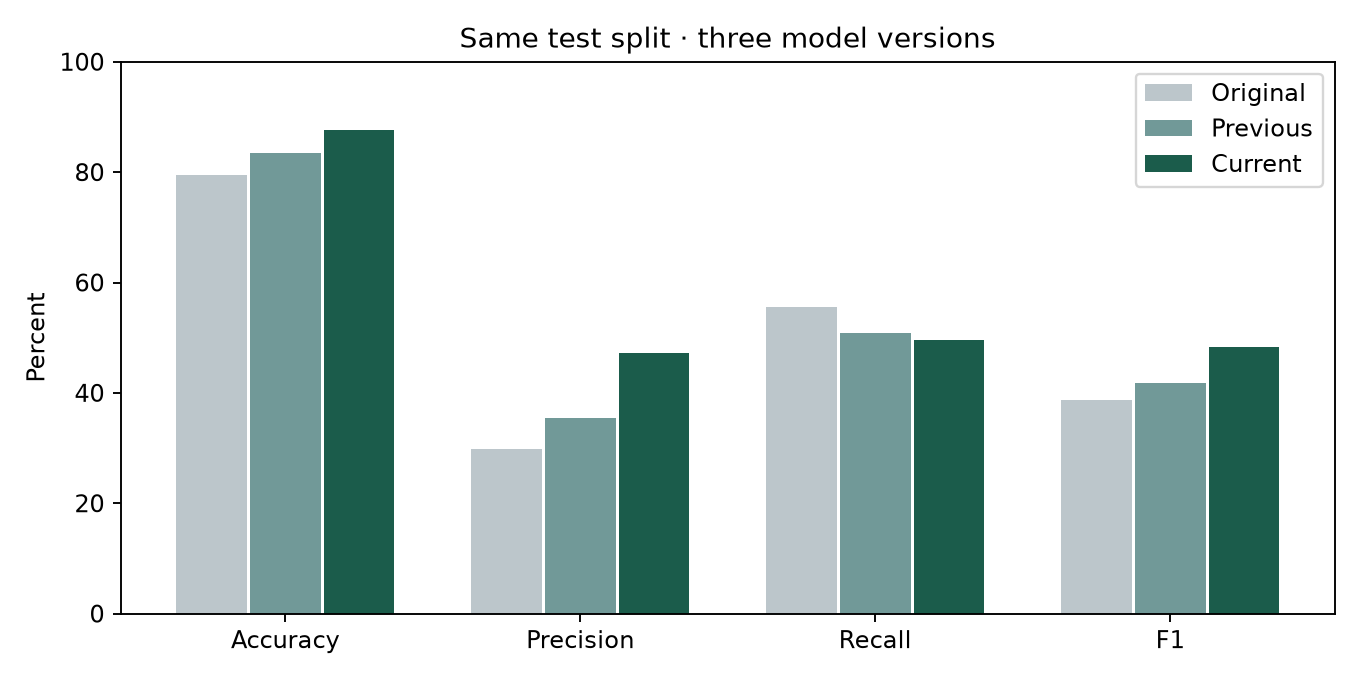

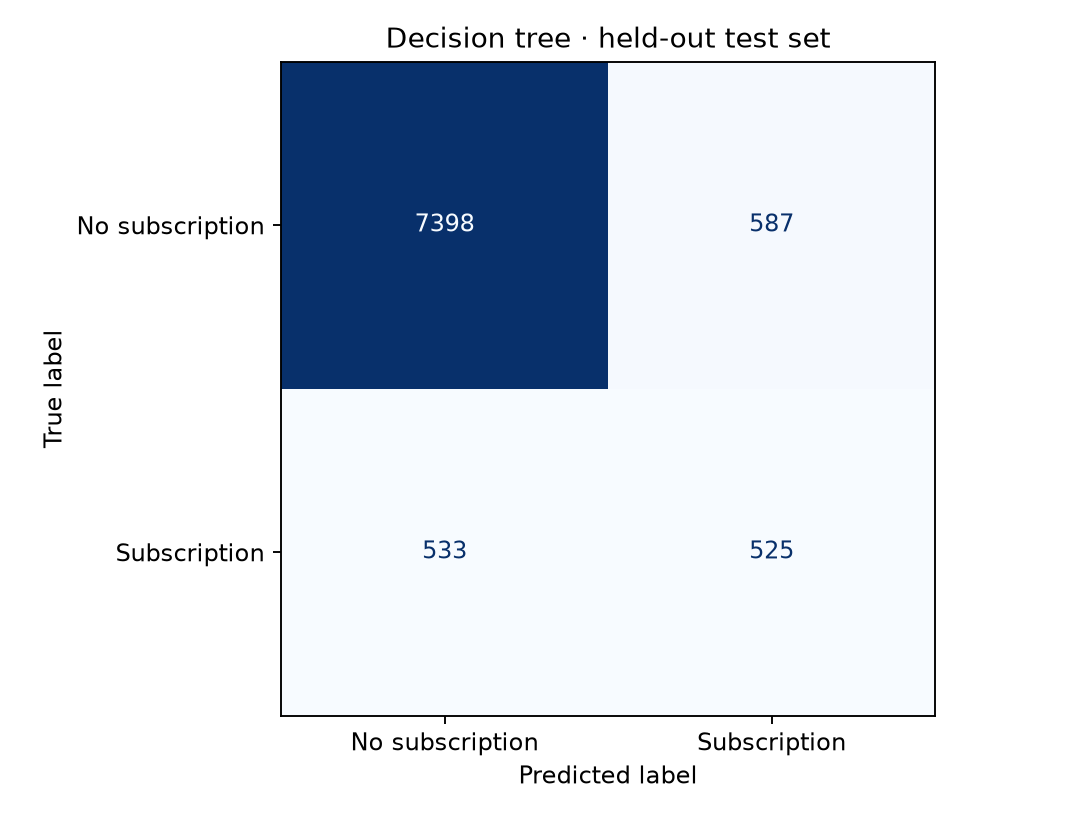

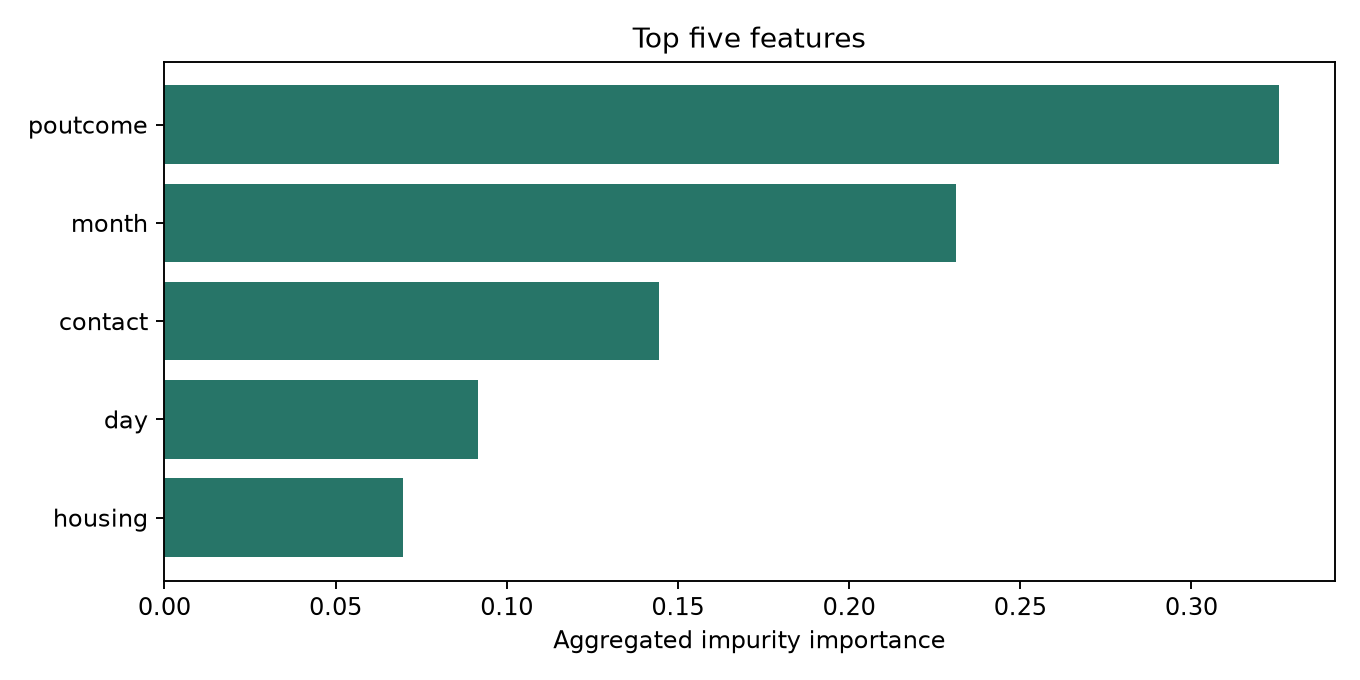

# Model summary

UCI Bank Marketing; 45,211 records. Same 80/20 stratified split, seed 42. Call duration excluded.

## Training-only selection

55 candidates: seven comparisons of prior settings, and 48 seeded random configurations spanning depths 6/8/10/12, leaf caps 32/64/128, minimum leaf sizes 20/50/100, pruning alpha 0/.0001/.0005/.001, Gini/entropy, and class weights none/balanced/2x/4x.

Five validation folds (seed 2026). Inside each validation-training partition, three inner folds produce out-of-fold scores for cutoff tuning. Choose the F1 cutoff using only those inner predictions, refit the candidate on that partition, then measure F1 on the separate validation fold. Fixed-cutoff comparison candidates use 0.5. Candidate means are selection scores, not unbiased final estimates: they are used to pick the winner.

Winner: expanded_28. Parameters: `{'min_samples_leaf': 20, 'max_leaf_nodes': 128, 'max_depth': 12, 'criterion': 'entropy', 'class_weight': {0: 1, 1: 4}, 'ccp_alpha': 0.0005}`.
Validation F1: 0.4736; previous configuration retuned under the same procedure: 0.4159.

After selection, tune the final cutoff on three out-of-fold partitions of all training data (seed 314), then fit the final pipeline on all training data. Cutoff: 0.579186; scores >= cutoff predict subscription. The model and cutoff are frozen before test evaluation.

## Same-split test evaluation

This test set was inspected for earlier versions. It is a regression comparison, not a fresh untouched benchmark. No test outcomes were used to choose this experiment's winner. External/prospective data is needed for an independent final assessment.

- accuracy: 0.8761
- precision: 0.4721
- recall: 0.4962
- f1: 0.4839
- average_precision: 0.4101
- roc_auc: 0.7829
- baseline_accuracy: 0.8830

Actual depth 12, 57 leaves. Top five features: [('poutcome', 0.3255151065624472), ('month', 0.23132849774722494), ('contact', 0.14458537684606215), ('day', 0.09151635105445106), ('housing', 0.06957879306103312)].

## Preprocessing and explanations

One-hot encoding is fitted inside each training fold; numerical fields pass through. Unknown categories and pdays=-1 are retained. When used, previously_contacted = int(pdays != -1) is derived automatically. Schedule and contact count must be known before the predicted call. Scores are uncalibrated, especially with class weights.

SHAP TreeExplainer uses training path counts. Baseline plus contributions equals the score. Browser inference sums exact per-leaf Shapley games and is checked against Python across test profiles and all test-reached leaves. The final cutoff determines class labels separately. Correlated features can share attribution; SHAP is not causal. Fairness and future-period performance are untested.

Saved pipeline and cutoff: outputs/trained_pipeline.joblib. Browser export: web/model.json. Load only trusted joblib files.

CSV SHA256: `d1513ec63b385506f7cfce9f2c5caa9fe99e7ba4e8c3fa264b3aaf0f849ed32d`


In [4]:
from IPython.display import display, Image, Markdown
display(pd.read_csv(ROOT/'outputs/experiment/candidate_results.csv').head(10))
display(pd.read_csv(ROOT/'outputs/model_comparison.csv'))
display(Image(filename=str(ROOT/'outputs/model_comparison.png')))
display(Image(filename=str(ROOT/'outputs/confusion_matrix.png')))
display(Image(filename=str(ROOT/'outputs/feature_importance.png')))
display(Markdown((ROOT/'outputs/model_summary.md').read_text(encoding='utf-8')))

## Explain an individual prediction

TreeExplainer uses tree-path-dependent training counts to explain class-1 scores. The baseline plus SHAP contributions equals the score. For a weighted tree, scores are not calibrated real-world probabilities. SHAP signals describe model associations; they do not prove why a customer acts.

In [5]:
row = X_test.iloc[[0]]
z = pipeline.named_steps['preprocess'].transform(row)
phi = explainer.shap_values(z)[0,:,1]
score = pipeline.predict_proba(row)[0,1]
assert abs(explainer.expected_value[1] + phi.sum() - score) < 1e-8
artifact = json.loads((ROOT/'web/model.json').read_text())
contributions = {}
for f, value in zip(artifact['features'], phi):
    contributions[f['source']] = contributions.get(f['source'], 0) + float(value)
yes = score >= metrics['decision_threshold']
ranked = sorted(contributions.items(), key=lambda item: abs(item[1]), reverse=True)
reasons = [(k,v) for k,v in ranked if (v>0 if yes else v<0)][:2]
print(f'The model predicts this customer will {"" if yes else "not "}subscribe because ' + ' and '.join(f'{k}={row.iloc[0][k]} pushes the subscription score {"up" if v>0 else "down"}' for k,v in reasons) + '.')
print(f'Model score: {score:.3f}; cutoff: {metrics["decision_threshold"]:.3f}; baseline: {explainer.expected_value[1]:.3f}')
display(pd.DataFrame(ranked, columns=['Feature', 'SHAP contribution']))

The model predicts this customer will not subscribe because contact=unknown pushes the subscription score down and poutcome=unknown pushes the subscription score down.
Model score: 0.090; cutoff: 0.579; baseline: 0.346


,Feature,SHAP contribution
0,contact,-0.115781
1,poutcome,-0.046838
2,housing,-0.042751
3,marital,-0.025426
4,month,-0.022829
5,day,0.003349
6,age,-0.002496
7,pdays,-0.002202
8,loan,-0.001739
9,campaign,-0.000919


## Reload the trained Python model

The joblib artifact contains the fitted preprocessing/model pipeline and decision cutoff. Only load trusted joblib files. Raw inputs need previously_contacted derived from pdays; predict.py does this automatically.

In [6]:
import joblib
saved = joblib.load(ROOT/'outputs/trained_pipeline.joblib')
np.testing.assert_allclose(saved['pipeline'].predict_proba(X_test.iloc[:10]), pipeline.predict_proba(X_test.iloc[:10]))
assert saved['decision_threshold'] == metrics['decision_threshold']
print('Reloaded pipeline matches the fitted model.')

Reloaded pipeline matches the fitted model.


## Limitations and deployment

Scores are uncalibrated; fairness and future-period performance are untested. Precision and recall may trade off. The browser uses exact per-leaf Shapley games, summing coalition products by size with polynomial coefficients to support deeper trees efficiently. Tests verify predictions, class labels, SHAP vectors and additivity across 100 test profiles plus each test-reached leaf. The cutoff determines labels separately from SHAP. Vercel remains paused.